In [6]:
from koala.voronization import generate_lattice
from koala.pointsets import uniform, bluenoise
from koala import graph_utils as gu
from koala import example_graphs as eg
from koala.lattice import Lattice
from koala.graph_color import color_lattice
from koala import plotting as pl
from tqdm import tqdm

from alter_morph.hamiltonians import (
    alt_hamiltonian,
    find_m_per_state,
    find_m_values,
    find_spin_per_state,
    fermi_probability,
    spectral_function,
)

from alter_morph.lattice_utilities import (
    add_contacts,
)

from copy import copy
import numpy as np
import matplotlib.pyplot as plt

import matplotlib

matplotlib.rcParams.update(
    {
        "font.size": 10,
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern"],
    }
)
aps_figwidth = 6.6
aps_halfwidth = 3.375

In [7]:
# generate the lattice
n_vertices = 20**2
points = uniform(n_vertices)

all_lattices = []

rows = np.round(np.sqrt(n_vertices)).astype(int)
all_lattices.append(eg.square_lattice(rows, rows))

vor_lat = generate_lattice(uniform(n_vertices // 2))
dimerisation = gu.dimerise(vor_lat)
all_lattices.append(gu.lloyd_relaxation(vor_lat, 10))

l2 = generate_lattice(uniform(n_vertices // 3))
l2 = gu.lloyd_relaxation(l2, 10)
exp_lat = gu.vertices_to_polygon(l2)
dimer_exp = np.zeros(exp_lat.n_edges)
dimer_exp[: l2.n_edges] = 1
all_lattices.append(gu.dimer_collapse(exp_lat, dimer_exp))


# fig, ax = plt.subplots(1, 3, figsize=(15, 5))
# for n, lat in enumerate(all_lattices):
#     pl.plot_edges(lat, ax=ax[n], alpha=1)
#     # print(lat)

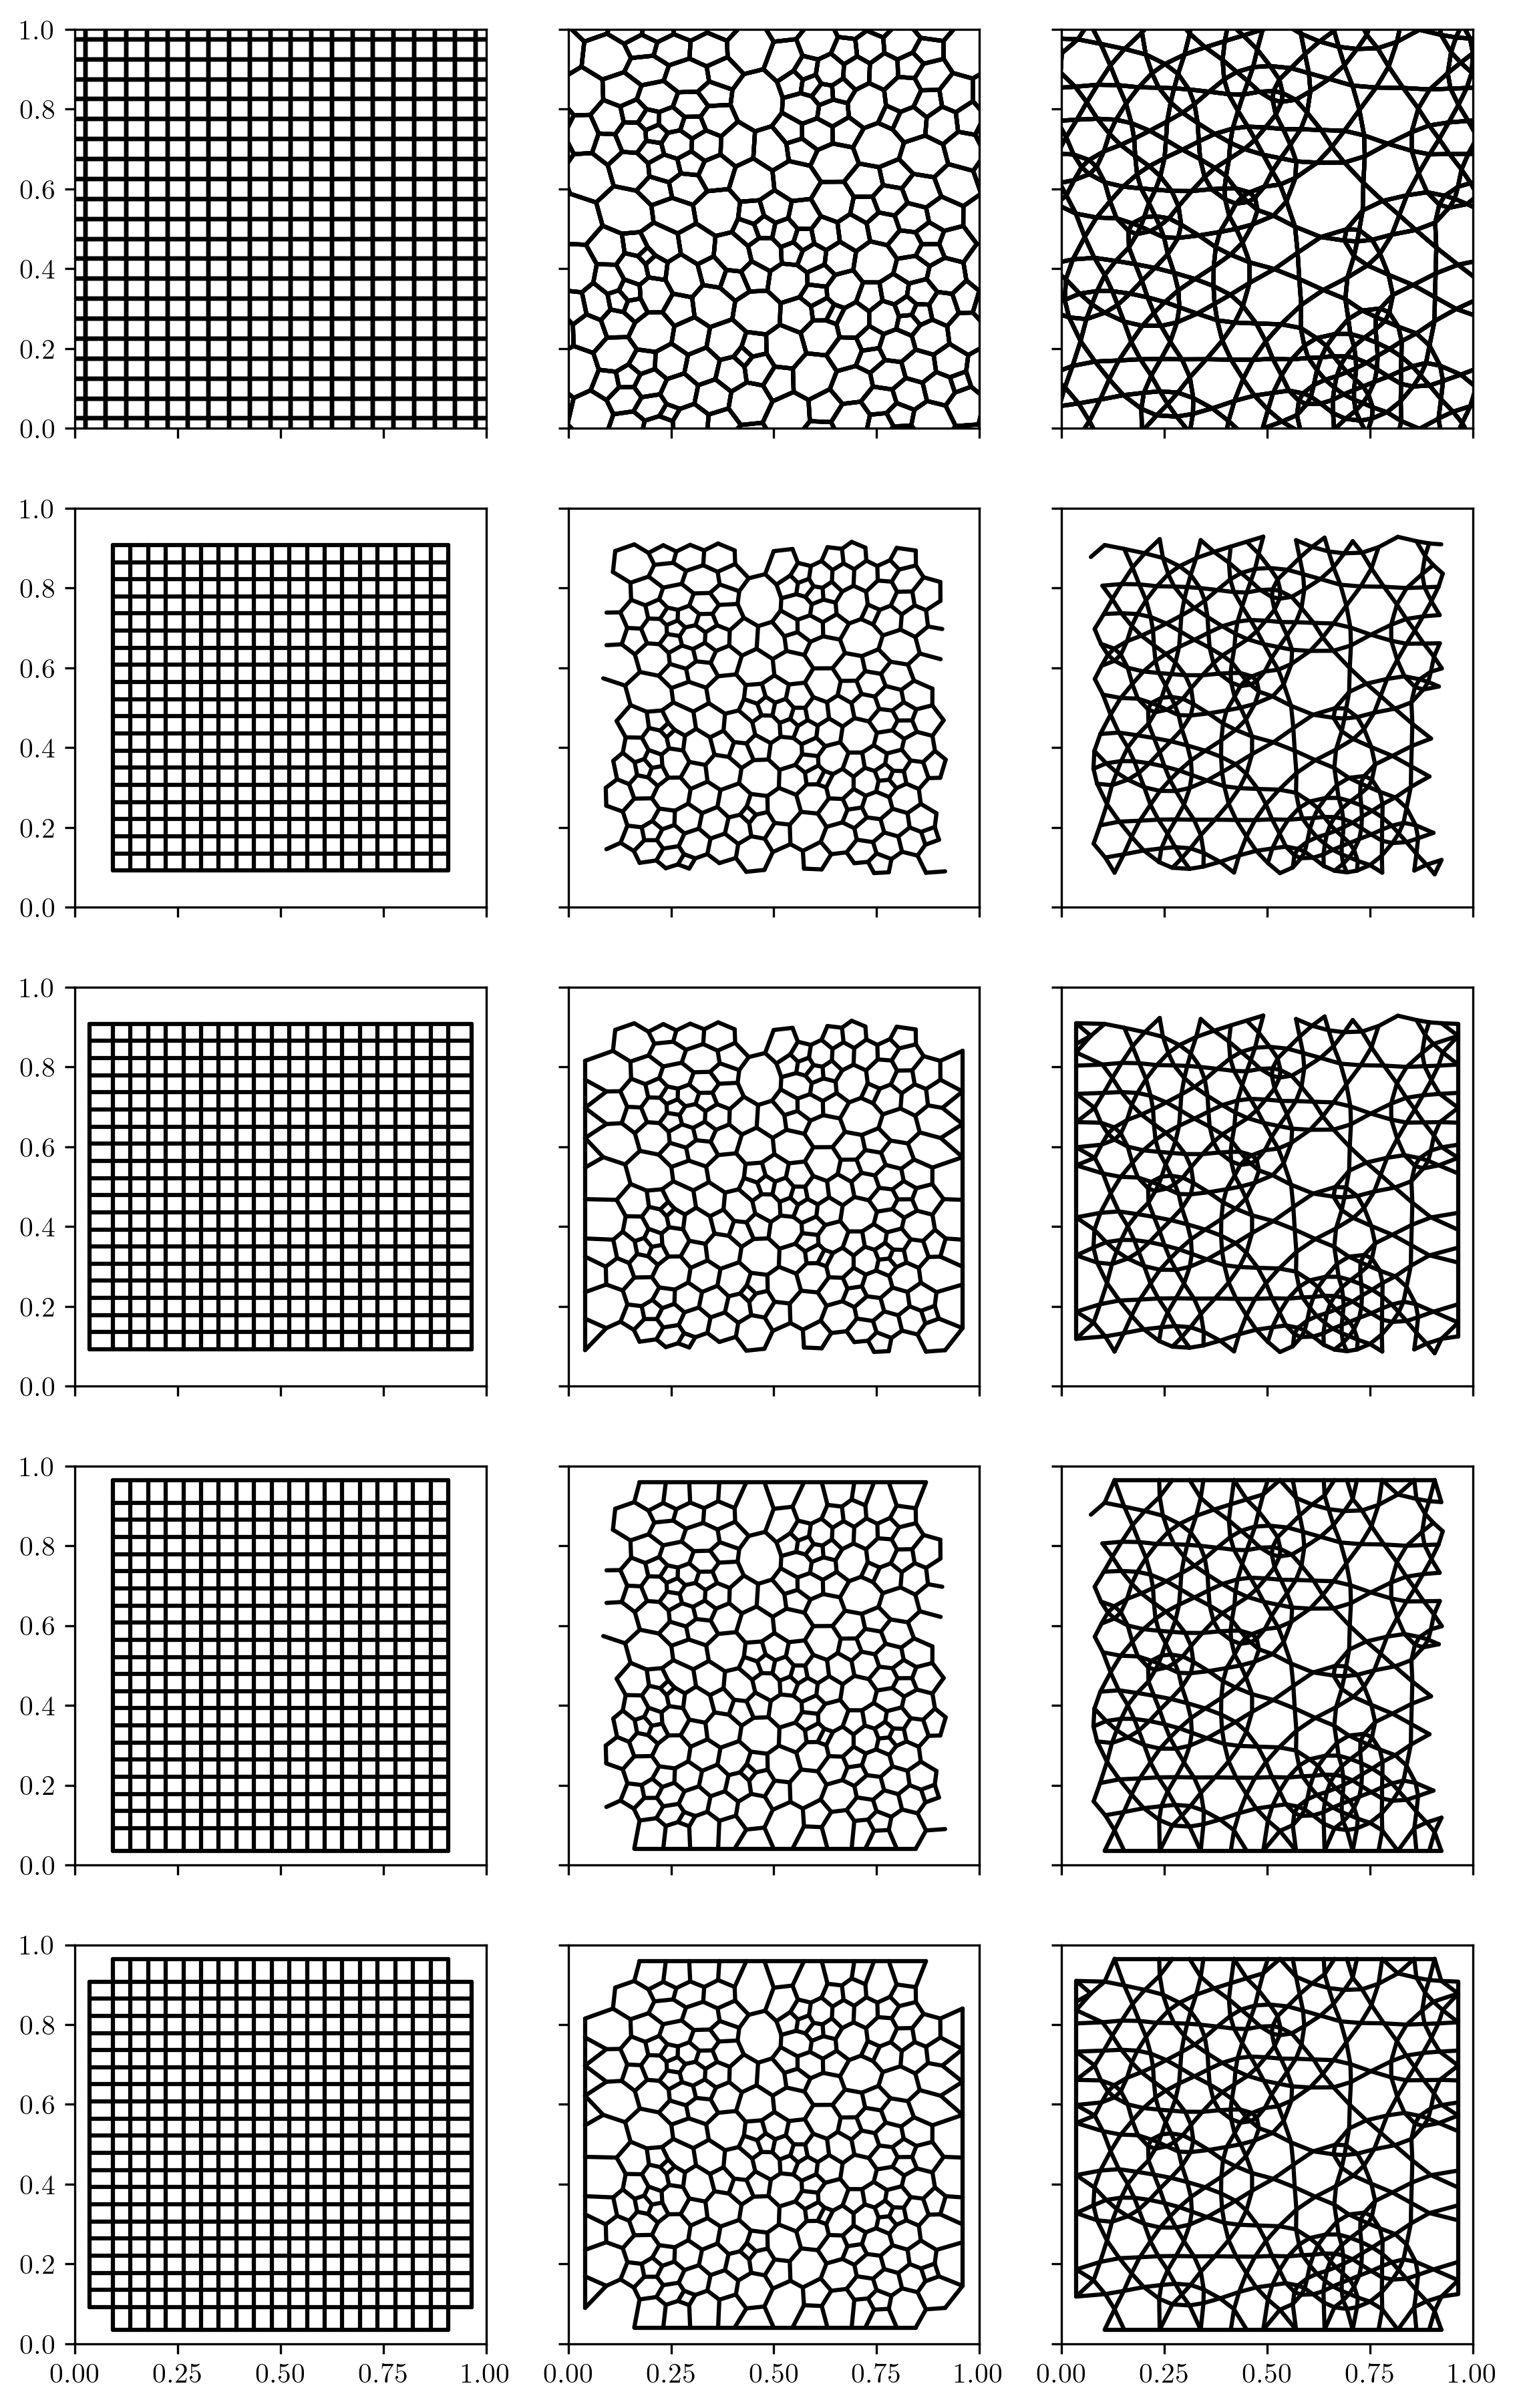

In [11]:
L = 3
fig, ax = plt.subplots(5, 3, figsize=(3 * L, 5 * L), sharex=True, sharey=True, dpi=300)

# for a in ax.flatten():
#     a.axis("off")

cut_types = (
    [False, False],
    [True, False],
    [False, True],
    [True, True],
)

for n, lat in enumerate(all_lattices):
    for m, cut in enumerate(cut_types):

        l_out, added_indices = add_contacts(
            lat,
            cut,
            cross_edges=True,
            make_uniform=False,
            return_added_indices=True,
        )
        pl.plot_edges(lat, ax=ax[0, n])
        pl.plot_edges(l_out, ax=ax[1 + m, n])

        colours = ["red", "blue", "green", "purple"]

        # for c, i, j in [("red", 0, 0), ("blue", 0, 1), ("green", 1, 0), ("purple", 1, 1)]:
        #     ax[1+m, n].scatter(
        #         l_out.vertices.positions[added_indices[i][j], 0],
        #         l_out.vertices.positions[added_indices[i][j], 1],
        #         color=c,
        #         s=10,
        #         zorder=10,
        #     )